In [4]:
"""
generate_data.py

"""

import os
import numpy as np
import pandas as pd
import cantera as ct

# ======================================================================
# CONFIGURATION
# ======================================================================
MECHANISM = r"grimech30_113.yaml" # Inster your mechanism file path
T0 = 1473.0
P = 51.013 * ct.one_atm
O2_CH4_RATIO = 0.59
STEAM_CH4_RATIO = 0.0
N2_CH4_RATIO = 0.012

T_END = 0.05
N_TIME_STEPS = 2000
ENFORCE_EXACT_COUNT = True
MIN_TIME_GAP = 1e-9

OUTPUT_DIR = "pox_data"          # Insert your desired output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)


def build_gas():
    gas = ct.Solution(MECHANISM)
    X = {"CH4": 1.0, "O2": O2_CH4_RATIO, "H2O": STEAM_CH4_RATIO, "N2": N2_CH4_RATIO}
    gas.TPX = T0, P, X
    return gas


# ======================================================================
# PASS 1: adaptive reference
# ======================================================================
def run_adaptive_reference():
    gas = build_gas()
    reactor = ct.IdealGasConstPressureReactor(gas, clone=False)
    sim = ct.ReactorNet([reactor])

    t_hist = [0.0]
    T_hist = [reactor.phase.T]
    Y_hist = [list(reactor.phase.Y)]

    while sim.time < T_END:
        sim.step()
        if sim.time > T_END:
            break
        t_hist.append(sim.time)
        T_hist.append(reactor.phase.T)
        Y_hist.append(list(reactor.phase.Y))

    t_hist = np.array(t_hist)
    T_hist = np.array(T_hist)
    Y_hist = np.array(Y_hist)
    print(f"Pass 1 (adaptive): solver took {len(t_hist)} internal steps to reach t_end")
    return t_hist, T_hist, Y_hist


# ======================================================================
# PASS 2: species-aware arc-length reparameterization
# ======================================================================
def arc_length_resample(t_hist, T_hist, Y_hist, n_points):
    log_t = np.log10(np.clip(t_hist, 1e-12, None))
    T_norm = (T_hist - T_hist.min()) / max(T_hist.max() - T_hist.min(), 1e-12)
    logt_norm = (log_t - log_t.min()) / max(log_t.max() - log_t.min(), 1e-12)

    d_Y = np.diff(Y_hist, axis=0)
    Y_change = np.linalg.norm(d_Y, axis=1)
    Y_change_norm = np.concatenate([[0.0], Y_change / max(Y_change.max(), 1e-12)])

    d_T = np.diff(T_norm)
    d_logt = np.diff(logt_norm)
    step_length = np.sqrt(d_T**2 + d_logt**2 + Y_change_norm[1:]**2)
    arc_length = np.concatenate([[0.0], np.cumsum(step_length)])

    target_s = np.linspace(0, arc_length[-1], n_points)
    resampled_t = np.interp(target_s, arc_length, t_hist)
    resampled_t = np.unique(resampled_t)
    return resampled_t[resampled_t > 0]


def filter_min_gap(times, min_gap=MIN_TIME_GAP):
    if len(times) == 0:
        return times
    kept = [times[0]]
    for t in times[1:]:
        if t - kept[-1] >= min_gap:
            kept.append(t)
    dropped = len(times) - len(kept)
    if dropped > 0:
        print(f"  Filtered {dropped} pathologically-close points (min_gap={min_gap:.0e}s)")
    return np.array(kept)


def fill_shortfall(times, n_target, t_end=T_END):
    if len(times) >= n_target:
        return times
    shortfall = n_target - len(times)
    full = np.concatenate(([0.0], times, [t_end]))
    gaps = np.diff(full)
    import heapq
    gap_heap = [(-g, i) for i, g in enumerate(gaps)]
    heapq.heapify(gap_heap)
    new_points = []
    for _ in range(shortfall):
        neg_gap, i = heapq.heappop(gap_heap)
        gap = -neg_gap
        new_t = full[i] + gap / 2
        new_points.append(new_t)
        heapq.heappush(gap_heap, (-(gap / 2), i))
    result = np.unique(np.concatenate([times, new_points]))
    result = result[(result > 0) & (result < t_end)]
    print(f"  fill_shortfall: added {shortfall} points -> {len(result)} points")
    return result


# ======================================================================
# VALIDATION CHECKS (Enhanced)
# ======================================================================
def run_validation_checks(gas, data, species_names):
    print("\n" + "="*60)
    print("VALIDATION CHECKS")
    print("="*60)
    
    T_col = data[:, 1]
    t_col = data[:, 0]
    n_species = gas.n_species
    Y_final = data[-1, 3:3 + n_species]

    print(f"Final T: {T_col[-1]:.1f} K   Max T: {T_col.max():.1f} K")

    # Element balance
    elements = ["C", "H", "O", "N"]
    gas.TPY = gas.T, gas.P, Y_final
    imbalance = 0.0
    gas0 = build_gas()
    for el in elements:
        initial_frac = gas0.elemental_mass_fraction(el)
        final_frac = gas.elemental_mass_fraction(el)
        imbalance = max(imbalance, abs(final_frac - initial_frac))
    print(f"Max element imbalance: {imbalance:.2e} (should be << 1e-10)")
    print(f"  ✅ Element balance PASSED" if imbalance < 1e-8 else "  ⚠️ Element balance CHECK")

    # Equilibrium check
    gas_eq = build_gas()
    gas_eq.TPY = T_col[-1], gas.P, Y_final
    gas_eq.equilibrate("TP")
    T_diff = abs(gas_eq.T - T_col[-1])
    print(f"Equilibrium T: {gas_eq.T:.1f} K (trajectory: {T_col[-1]:.1f} K)")
    print(f"  T difference: {T_diff:.1f} K")
    print(f"  ✅ Equilibrium check PASSED" if T_diff < 50 else "  ⚠️ Equilibrium check")

    # Resolution check
    T_min, T_max = T_col.min(), T_col.max()
    lo_idx = np.argmax(T_col > T_min + 0.05 * (T_max - T_min))
    hi_idx = np.argmax(T_col > T_min + 0.95 * (T_max - T_min))
    n_in_rise = ((t_col >= t_col[lo_idx]) & (t_col <= t_col[hi_idx])).sum()
    pct_in_rise = n_in_rise / len(t_col) * 100
    print(f"Points in ignition region: {n_in_rise}/{len(t_col)} ({pct_in_rise:.1f}%)")
    print(f"  ✅ Good ignition coverage" if pct_in_rise > 30 else "  ⚠️ Low ignition coverage")

    # Gap sanity
    gaps = np.diff(t_col)
    print(f"Smallest time gap: {gaps.min():.3e} s")
    print(f"Largest time gap: {gaps.max():.3e} s")
    print(f"Unique times: {len(t_col) == len(set(t_col))}")
    print(f"  ✅ No duplicates" if len(t_col) == len(set(t_col)) else "  ⚠️ Duplicates found")

    # Derivative check
    dT_col = data[:, 2]
    dT_max = np.abs(dT_col).max()
    print(f"Max |dT/dt|: {dT_max:.2e} K/s")
    if dT_max > 1e10:
        print("  ⚠️ Very large derivatives - may need scaling for Neural ODE")
    else:
        print("  ✅ Derivative magnitudes reasonable")

    # Species range check
    print("\nSpecies ranges:")
    for i, sp in enumerate(species_names[:6]):  # First 6 species
        Y = data[:, 3+i]
        if Y.max() - Y.min() > 1e-6:
            print(f"  {sp:>6}: [{Y.min():.2e}, {Y.max():.2e}] ✓")
        else:
            print(f"  {sp:>6}: [{Y.min():.2e}, {Y.max():.2e}] ⚠️ small range")


def generate_dataset():
    t_hist, T_hist, Y_hist = run_adaptive_reference()

    time_grid = arc_length_resample(t_hist, T_hist, Y_hist, N_TIME_STEPS)
    time_grid = filter_min_gap(time_grid)
    print(f"Pass 2: species-aware arc-length-resampled + gap-filtered: {len(time_grid)} points")

    if ENFORCE_EXACT_COUNT and len(time_grid) < N_TIME_STEPS:
        time_grid = fill_shortfall(time_grid, N_TIME_STEPS)
        time_grid = filter_min_gap(time_grid)
        print(f"After exact-count fill + re-filter: {len(time_grid)} points")

    gas = build_gas()
    reactor = ct.IdealGasConstPressureReactor(gas, clone=False)
    sim = ct.ReactorNet([reactor])
    species_names = gas.species_names
    mw = gas.molecular_weights

    data = []
    for t in np.concatenate(([0.0], time_grid)):
        sim.advance(t)
        T = reactor.phase.T
        Y = reactor.phase.Y
        wdot = reactor.phase.net_production_rates
        rho = reactor.phase.density
        cp = reactor.phase.cp_mass
        h_partial = reactor.phase.partial_molar_enthalpies

        dY_dt = wdot * mw / rho
        dT_dt = -np.dot(h_partial, wdot) / (rho * cp)
        data.append([t, T, dT_dt] + list(Y) + list(dY_dt))

    data = np.array(data)
    col_names = ["t", "T", "dT_dt"] + species_names + [f"dY_dt_{sp}" for sp in species_names]
    df = pd.DataFrame(data, columns=col_names)

    # Save as CSV
    csv_path = os.path.join(OUTPUT_DIR, "single_case.csv")
    df.to_csv(csv_path, index=False)
    print(f"\n✓ Saved: {csv_path} ({df.shape[0]} rows)")

    

    metadata = {
        "mechanism": MECHANISM, "T0": T0, "P_bar": P / ct.one_atm,
        "O2_CH4": O2_CH4_RATIO, "H2O_CH4": STEAM_CH4_RATIO,
        "column_names": col_names, "n_species": gas.n_species,
        "min_time_gap": MIN_TIME_GAP,
        "n_points": len(df),
        "t_end": T_END,
    }
    np.savez(os.path.join(OUTPUT_DIR, "single_case_metadata.npz"), **metadata)

    run_validation_checks(gas, data, species_names)
    return df


if __name__ == "__main__":
    df = generate_dataset()
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"✓ Generated {len(df)} data points")
    print(f"✓ Species: {df.shape[1] - 3} species")
    print(f"✓ Time range: [{df['t'].min():.2e}, {df['t'].max():.2e}] s")
    print(f"✓ Temperature range: [{df['T'].min():.1f}, {df['T'].max():.1f}] K")
    print("\nData ready for Neural ODE training!")
    print("="*60)

Pass 1 (adaptive): solver took 3028 internal steps to reach t_end
  Filtered 165 pathologically-close points (min_gap=1e-09s)
Pass 2: species-aware arc-length-resampled + gap-filtered: 1834 points
  fill_shortfall: added 166 points -> 2000 points
After exact-count fill + re-filter: 2000 points

✓ Saved: pox_data\single_case.csv (2001 rows)

VALIDATION CHECKS
Final T: 2130.1 K   Max T: 2492.9 K
Max element imbalance: 1.22e-15 (should be << 1e-10)
  ✅ Element balance PASSED
Equilibrium T: 2130.1 K (trajectory: 2130.1 K)
  T difference: 0.0 K
  ✅ Equilibrium check PASSED
Points in ignition region: 764/2001 (38.2%)
  ✅ Good ignition coverage
Smallest time gap: 2.465e-10 s
Largest time gap: 1.523e-02 s
Unique times: True
  ✅ No duplicates
Max |dT/dt|: 8.85e+08 K/s
  ✅ Derivative magnitudes reasonable

Species ranges:
      H2: [0.00e+00, 1.05e-01] ✓
       H: [0.00e+00, 1.32e-04] ✓
       O: [0.00e+00, 5.19e-05] ✓
      O2: [2.23e-10, 5.35e-01] ✓
      OH: [0.00e+00, 6.38e-04] ✓
     H2O: [

Re-running Pass 1 (adaptive reference) for plotting...
Pass 1 (adaptive): solver took 3028 internal steps to reach t_end
Loaded 2001 sampled points from pox_data/single_case.csv
Saved temperature_comparison.png
Saved species_comparison.png


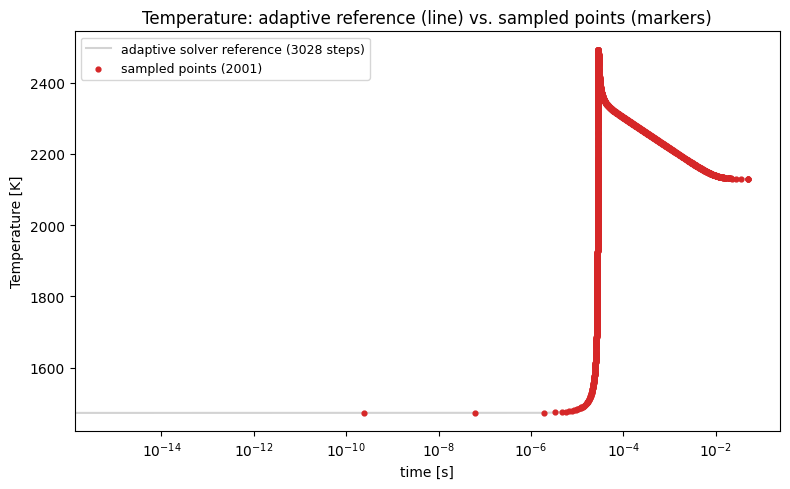

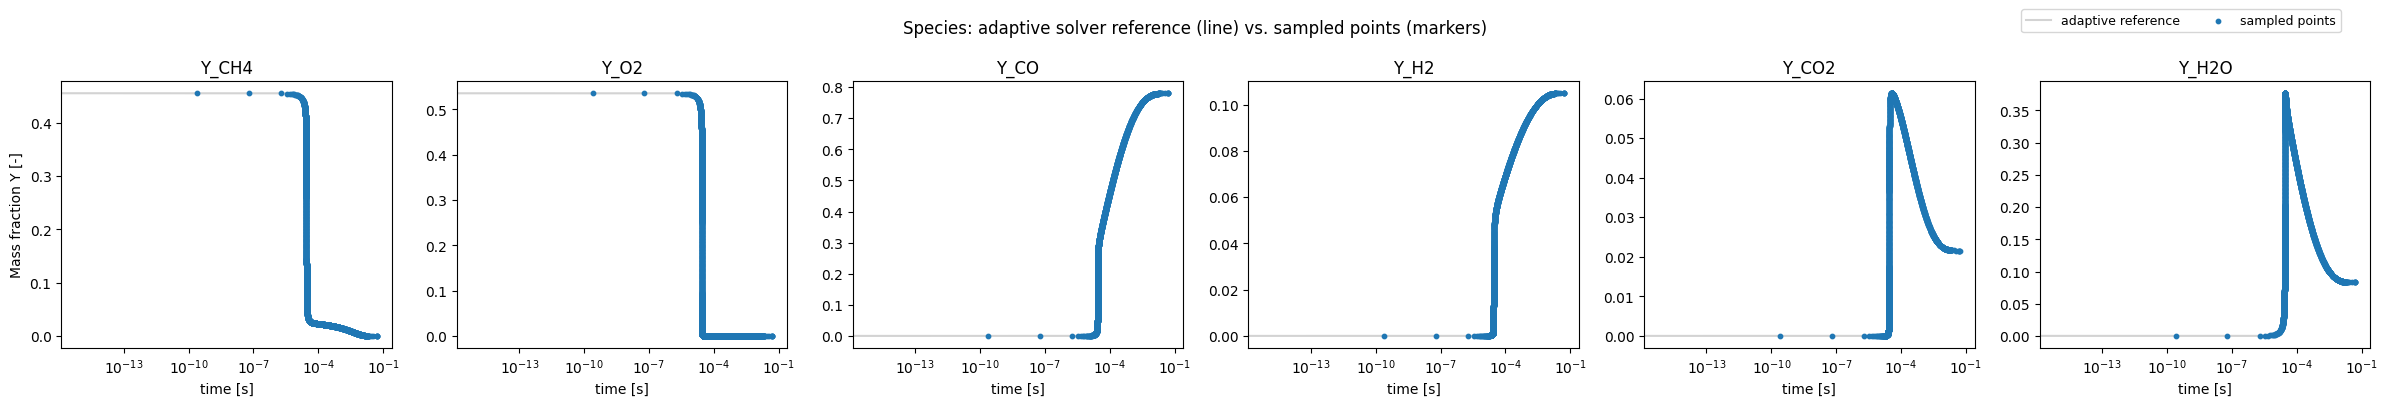

In [5]:
"""
plot_data.py

  1. Temperature vs. time.
  2. Major species mass fractions vs. time.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CSV_PATH = f"{OUTPUT_DIR}/single_case.csv"
DEFAULT_SPECIES = ["CH4", "O2", "CO", "H2", "CO2", "H2O"]


def load_sampled_data(path=CSV_PATH):
    df = pd.read_csv(path)
    species_cols = [c for c in df.columns if not c.startswith("d") and c not in ("t", "T", "dT_dt")]
    return df, species_cols


def plot_temperature(t_hist, T_hist, df):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(t_hist, T_hist, "-", color="lightgray", lw=1.5, zorder=1,
            label=f"adaptive solver reference ({len(t_hist)} steps)")
    ax.scatter(df["t"], df["T"], s=12, color="tab:red", zorder=2,
               label=f"sampled points ({len(df)})")
    ax.set_xscale("log")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("Temperature [K]")
    ax.legend(fontsize=9)
    ax.set_title("Temperature: adaptive reference (line) vs. sampled points (markers)")
    fig.tight_layout()
    fig.savefig("temperature_comparison.png", dpi=150)
    print("Saved temperature_comparison.png")


def plot_species(t_hist, Y_hist, species_names, df, species_to_plot=DEFAULT_SPECIES):
    n = len(species_to_plot)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharex=True)
    for ax, sp in zip(axes, species_to_plot):
        idx = species_names.index(sp)
        ax.plot(t_hist, Y_hist[:, idx], "-", color="lightgray", lw=1.5, zorder=1)
        ax.scatter(df["t"], df[sp], s=10, color="tab:blue", zorder=2)
        ax.set_title(f"Y_{sp}")
        ax.set_xlabel("time [s]")
        ax.set_xscale("log")
    axes[0].set_ylabel("Mass fraction Y [-]")
    fig.suptitle("Species: adaptive solver reference (line) vs. sampled points (markers)")
    # single shared legend, built manually since each subplot repeats the same two series
    fig.legend(["adaptive reference", "sampled points"], loc="upper right",
               ncol=2, fontsize=9, bbox_to_anchor=(0.98, 1.02))
    fig.tight_layout()
    fig.savefig("species_comparison.png", dpi=150)
    print("Saved species_comparison.png")


if __name__ == "__main__":
    print("Re-running Pass 1 (adaptive reference) for plotting...")
    t_hist, T_hist, Y_hist = run_adaptive_reference()
    species_names = build_gas().species_names

    df, species_cols = load_sampled_data()
    print(f"Loaded {len(df)} sampled points from {CSV_PATH}")

    plot_temperature(t_hist, T_hist, df)
    plot_species(t_hist, Y_hist, species_names, df)